## **Business context**
You are provided with a real data set to identify anomalous activity in a ship’s engine functionality (Devabrat,  2022). As you work through this project, keep in mind that, typically speaking, anomalies would make up a minority of the data points (i.e., about 1% to 5% of the data points would be anomalies).

The data set contains six important features continuously monitored to evaluate the engine's status as ‘good’ or ‘bad’. These features are:
- **Engine rpm (revolutions per minute):** A high rpm indicates the engine is operating at a higher speed than designed for prolonged periods, which can lead to overheating, excessive wear, and eventual failure. A low rpm could signal a lack of power, issues with fuel delivery, or internal mechanical problems.
- **Lubrication oil pressure:** Low lubrication oil pressure indicates insufficient lubrication, leading to increased friction, overheating, and engine damage. A high lubrication oil pressure could signal a blockage in the oil delivery system, potentially causing seal or gasket failure.
- **Fuel pressure:** High fuel pressure can cause poor engine performance and incomplete combustion, indicating fuel pump or filter issues. A low fuel pressure may result in excessive fuel consumption, poor emissions, or damage to the fuel injectors.
- **Coolant pressure:** Low coolant pressure indicates a potential leak in the cooling system or a coolant pump failure, risking engine overheating. A high coolant pressure could be a sign of a blockage in the cooling system or a failing head gasket, which can also lead to overheating.
- **Lubrication oil temperature:** High lubrication oil temperature suggests the oil is overheating, which can degrade its lubricating properties and lead to engine damage. A low lubrication oil temperature may indicate it is not reaching its optimal operating temperature, potentially causing inadequate lubrication.
- **Coolant temperature:** High coolant temperature signals overheating, which various issues, including a failed thermostat, coolant leak, or insufficient coolant flow can cause. A low coolant temperature could suggest the engine is not reaching its optimal operating temperature, affecting performance and efficiency.

Issues with engines could lead to engine malfunctions, potential safety hazards, and downtime (e.g. delayed deliveries), resulting in the breakdown of a ship’s overall functionality, consequently impacting the business, such as affecting revenue via failure to deliver goods. By predicting timely maintenance, the business aims to increase profit by reducing downtime, reducing safety risks for the crew, limiting fuel consumption, and increasing customer satisfaction through timely deliveries.

Your task is to develop a robust anomaly detection system to protect a company’s shipping fleet by evaluating engine functionality. Therefore, you’ll explore the data and:
- employ preprocessing and feature engineering
- perform anomaly detection.

You must prepare a report illustrating your insights to the prospective stakeholders, explaining your approach in identifying anomalies, presenting your findings and including recommendations.

<br></br>

> **Disclaimer**
>
> Please note that although a real-life data set was provided, the business context in this project is fictitious. Any resemblance to companies and persons (living or dead) is coincidental. The course designers and hosts assume no responsibility or liability for any errors or omissions in the content of the business context and data sets. The information in the data sets is provided on an 'as is' basis with no guarantees of completeness, accuracy, usefulness, or timeliness.

<br></br>

## **Objective**
By the end of this mini-project, you will be able to understand and apply statistical and ML methods for detecting anomalies.

In the Notebook, you will:
- explore the data set
- preprocess the data and conduct feature engineering
- apply statistical techniques to detect anomalies
- use ML algorithms to detect anomalies.

You will also write a report summarising the results of your findings and recommendations.

<br></br>

## **Assessment criteria**
By completing this project, you will be able to provide evidence that you can:
- demonstrate enhanced problem-solving skills and proposed strategic solutions by systematically analysing complex organisational challenges
- identify meaningful patterns in complex data to evidence advanced critical and statistical thinking skills
- select statistical techniques appropriate to a solutions design approach and evidence the ability to evaluate their effectiveness
- demonstrate enhanced data representation and improved model performance by systematically implementing relevant techniques
- design innovative solutions through critically selecting, evaluating and implementing effective unsupervised learning techniques.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest


# Exploring the data set

In [ ]:
#import and read the data
url = 'https://raw.githubusercontent.com/fourthrevlxd/cam_dsb/main/engine.csv'
df = pd.read_csv(url)

In [ ]:
print(f"view data frame : \n{df.head()}")

view data frame : 
   Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
0         682          2.391656       4.617196          2.848982   
1         605          5.466877       6.424361          5.727520   
2         658          3.434232       3.680896          1.678708   
3         749          2.094656       7.120927          1.639670   
4         676          3.538228       5.956472          3.225336   

   lub oil temp  Coolant temp  
0     76.272417     69.884609  
1     73.222679     74.907314  
2     88.089916     78.704806  
3     77.661625     82.386700  
4     75.226352     67.153220  


In [ ]:
df.head().T

,0,1,2,3,4
Engine rpm,682.000000,605.000000,658.000000,749.000000,676.000000
Lub oil pressure,2.391656,5.466877,3.434232,2.094656,3.538228
Fuel pressure,4.617196,6.424361,3.680896,7.120927,5.956472
Coolant pressure,2.848982,5.727520,1.678708,1.639670,3.225336
lub oil temp,76.272417,73.222679,88.089916,77.661625,75.226352
Coolant temp,69.884609,74.907314,78.704806,82.386700,67.153220


In [ ]:
print(f"missing values : \n{df.isna().sum()}")

missing values : 
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64


In [ ]:
print(f"null values : \n{df.isnull().sum()}")

null values : 
Engine rpm          0
Lub oil pressure    0
Fuel pressure       0
Coolant pressure    0
lub oil temp        0
Coolant temp        0
dtype: int64


In [ ]:
print(f"duplicate values : \n{df.duplicated().sum()}")

duplicate values : 
0


## statistics of the data



In [ ]:
print(f"view summary statistics of the data  : \n{df.describe()}")

view summary statistics of the data  : 
         Engine rpm  Lub oil pressure  Fuel pressure  Coolant pressure  \
count  19535.000000      19535.000000   19535.000000      19535.000000   
mean     791.239263          3.303775       6.655615          2.335369   
std      267.611193          1.021643       2.761021          1.036382   
min       61.000000          0.003384       0.003187          0.002483   
25%      593.000000          2.518815       4.916886          1.600466   
50%      746.000000          3.162035       6.201720          2.166883   
75%      934.000000          4.055272       7.744973          2.848840   
max     2239.000000          7.265566      21.138326          7.478505   

       lub oil temp  Coolant temp  
count  19535.000000  19535.000000  
mean      77.643420     78.427433  
std        3.110984      6.206749  
min       71.321974     61.673325  
25%       75.725990     73.895421  
50%       76.817350     78.346662  
75%       78.071691     82.915411  
max  

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Engine rpm,19535.0,791.239263,267.611193,61.000000,593.000000,746.000000,934.000000,2239.000000
Lub oil pressure,19535.0,3.303775,1.021643,0.003384,2.518815,3.162035,4.055272,7.265566
Fuel pressure,19535.0,6.655615,2.761021,0.003187,4.916886,6.201720,7.744973,21.138326
Coolant pressure,19535.0,2.335369,1.036382,0.002483,1.600466,2.166883,2.848840,7.478505
lub oil temp,19535.0,77.643420,3.110984,71.321974,75.725990,76.817350,78.071691,89.580796
Coolant temp,19535.0,78.427433,6.206749,61.673325,73.895421,78.346662,82.915411,195.527912


The Engine rpm has the highest mean, while Coolant pressure has the lowest. For most features, the mean and median are close, indicating that the data is approximately symmetric. However, the mean is often slightly higher than the median, suggesting a mild right-skewness. Additionally, some large maximum values (e.g., in coolant temperature) indicate the presence of possible outliers, meaning the data is not perfectly normally distributed.

## distribution and extreme values

In [ ]:
df_columns = ["Engine rpm", "Lub oil pressure", "Fuel pressure",
           "Coolant pressure", "lub oil temp", "Coolant temp"]

In [ ]:
def visualize_data():
    for col in df_columns:
        plt.figure(figsize=(14, 6))
        # histogram
        plt.subplot(1, 2, 1)
        sns.histplot(df[col], kde=True, bins=10, color="blue")
        plt.title(f'Distribution of {col}')
        # boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[col], color="green")
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
    plt.show()

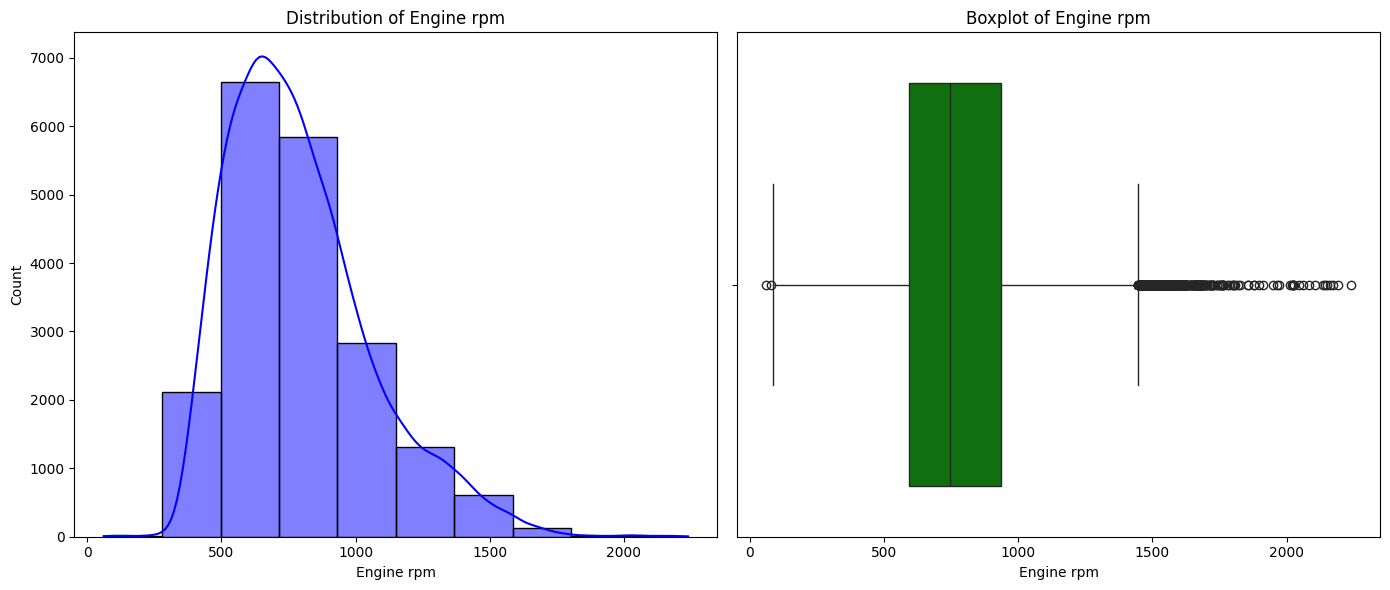

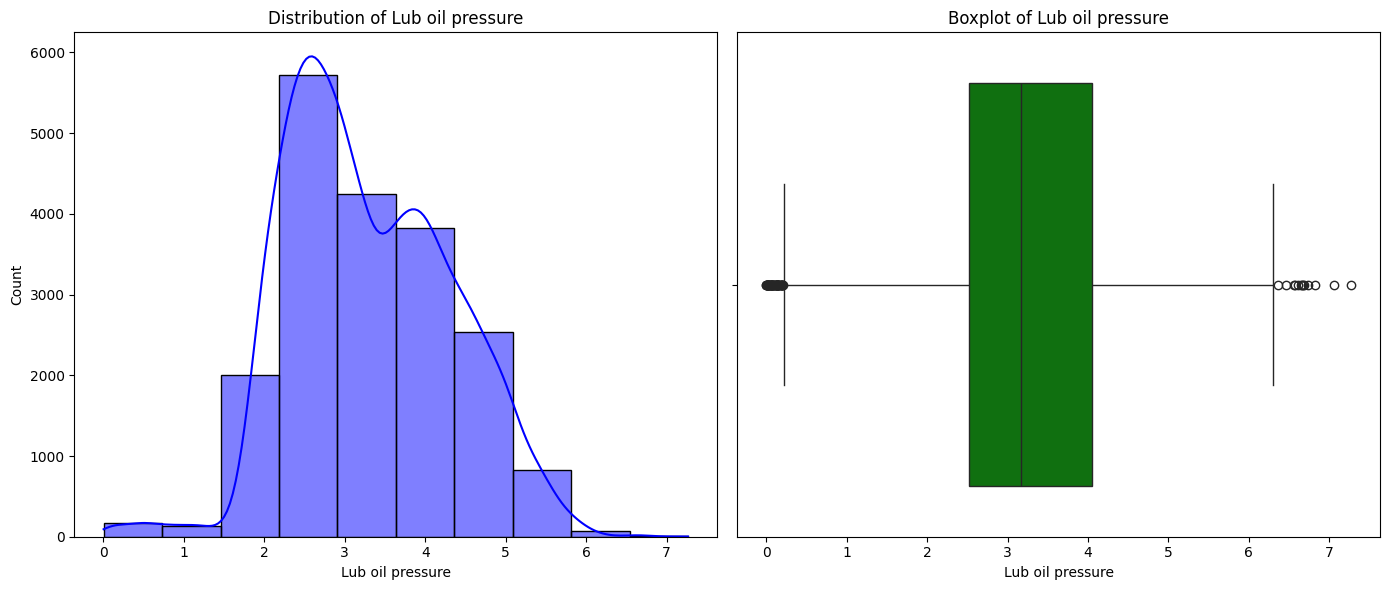

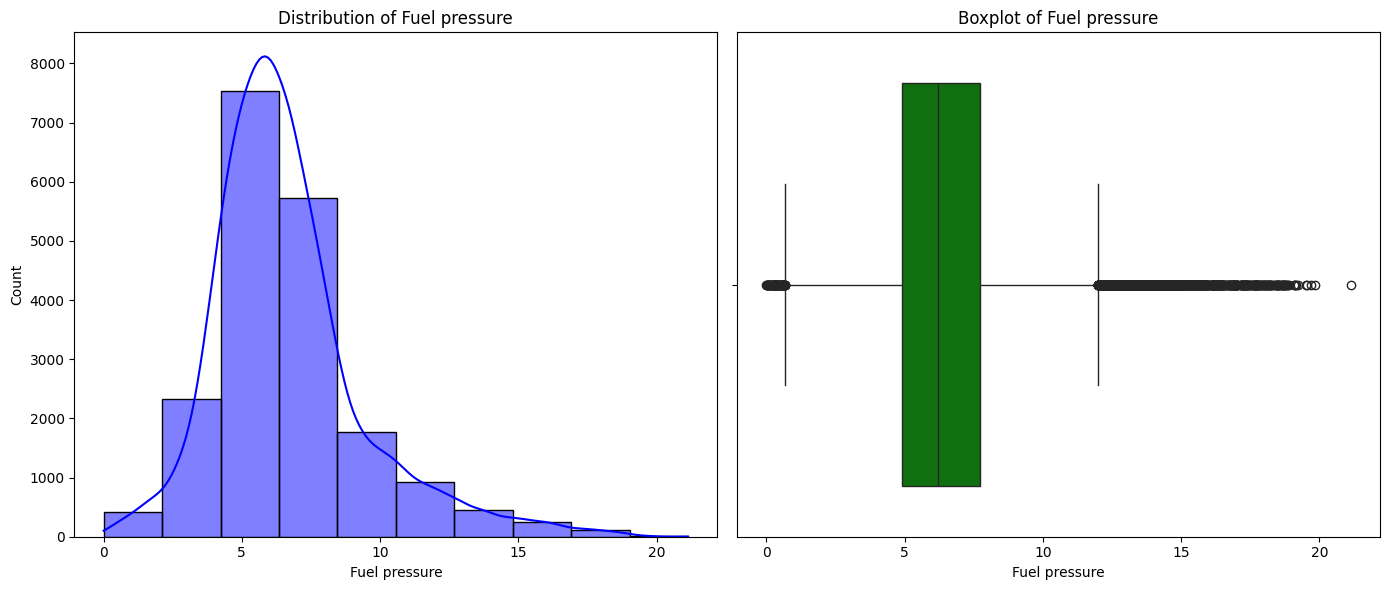

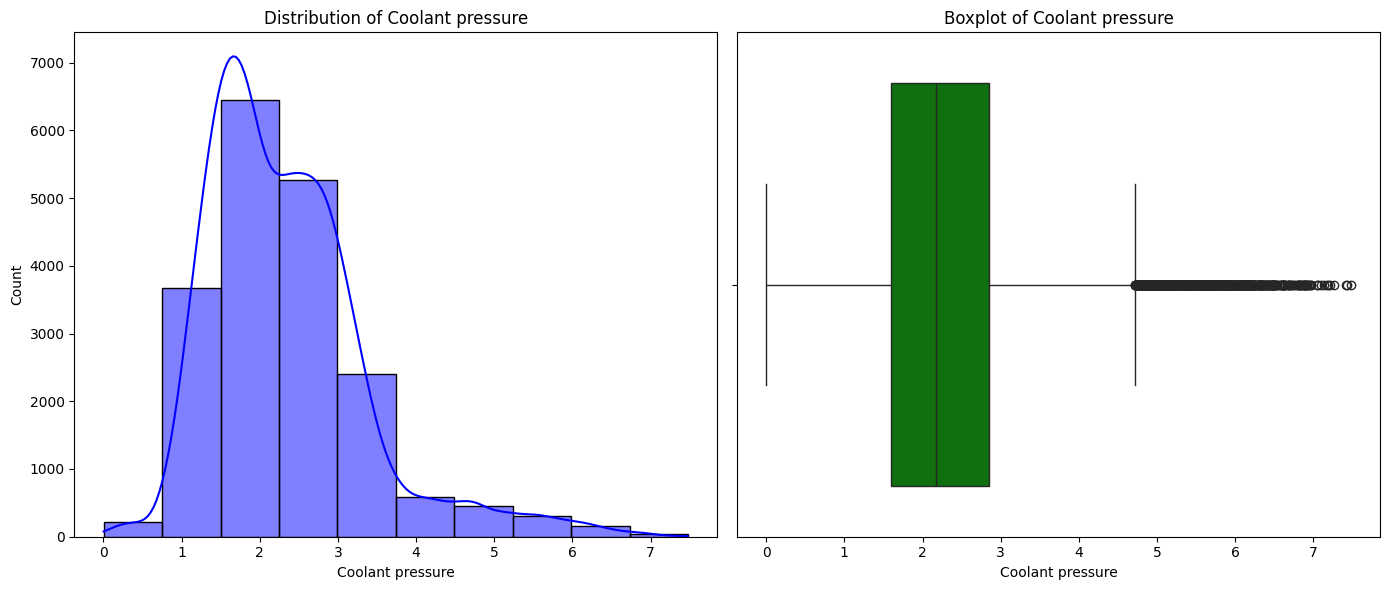

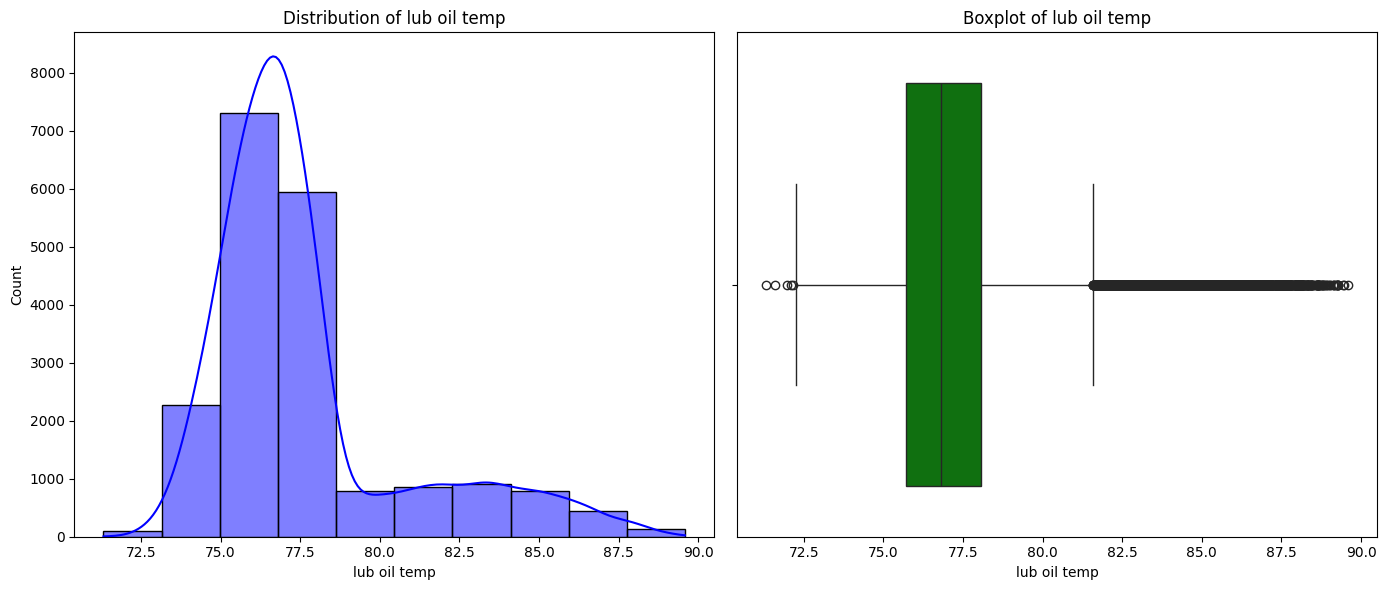

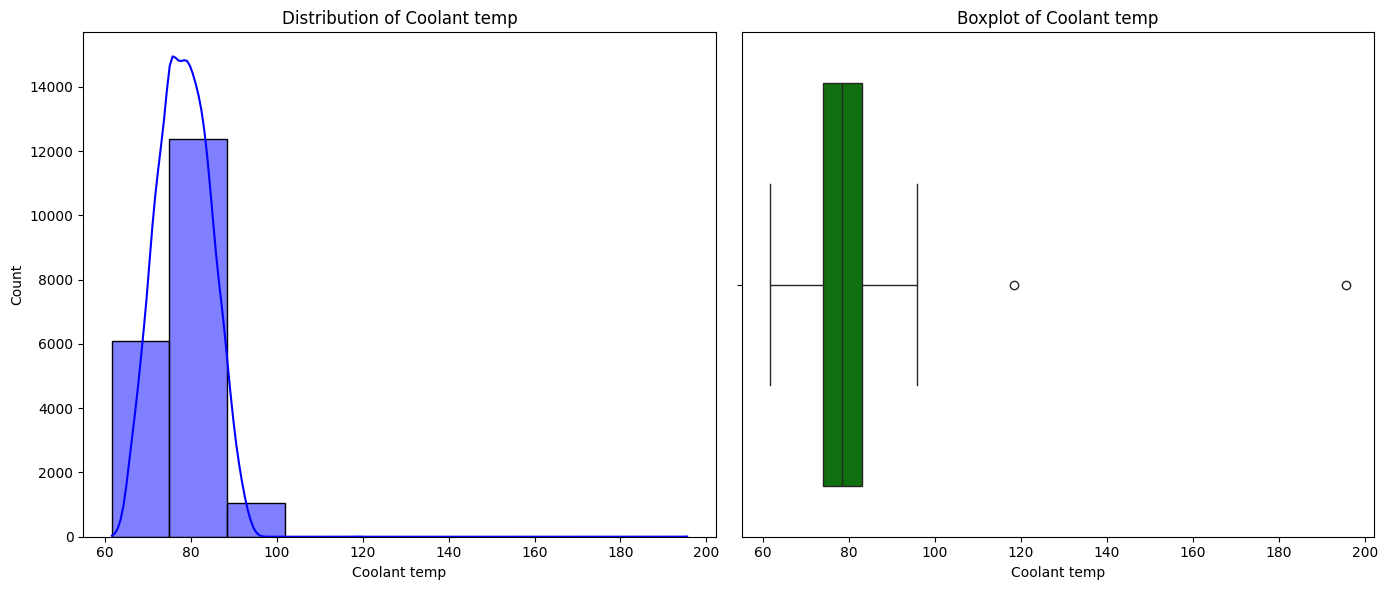

In [ ]:
visualize_data()

> The histograms show that most features are not perfectly normally distributed

> The boxplots reveal multiple points outside the interquartile range for each feature, indicating the presence of potential outliers.





# Anomaly detection

## IQR

In [ ]:
def calc_iqr():
    """
    Function to calculate IQR for each feature
    and create binary outlier columns.
    """
    for col in df_columns:
        q1 = df[col].quantile(0.25)
        q3 = df[col].quantile(0.75)
        iqr = q3 - q1

        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr

        outliers = df[(df[col] < lower) | (df[col] > upper)]
        percentage = len(outliers) / len(df) * 100
        df[f"{col}_outlier"] = ((df[col] < lower) | (df[col] > upper)).astype(int)

        print(col, "outliers:", len(outliers))
        print("Percentage:", percentage)
        print("\n")

    #identify the number of features that in outlier condition --- threshold
    outlier_cols = [f"{col}_outlier" for col in df_columns]
    df["num_outlier_features"] = df[outlier_cols].sum(axis=1)
    total = len(df)
    for t in range(1, 7):
        count = (df["num_outlier_features"] >= t).sum()
        percent = count / total * 100
        print(f"threshold {t} -> {count} samples ({percent:.2f}%)")

    outlier_cols = [f"{col}_outlier" for col in df_columns]
    print("\nBinary Outlier Columns:\n")
    print(df[outlier_cols])


In [ ]:
calc_iqr()

Engine rpm outliers: 464
Percentage: 2.375223957000256


Lub oil pressure outliers: 66
Percentage: 0.3378551318146916


Fuel pressure outliers: 1135
Percentage: 5.810084463782954


Coolant pressure outliers: 785
Percentage: 4.018428461735347


lub oil temp outliers: 2617
Percentage: 13.396467878167392


Coolant temp outliers: 2
Percentage: 0.010238034297414897


threshold 1 -> 4636 samples (23.73%)
threshold 2 -> 422 samples (2.16%)
threshold 3 -> 11 samples (0.06%)
threshold 4 -> 0 samples (0.00%)
threshold 5 -> 0 samples (0.00%)
threshold 6 -> 0 samples (0.00%)

Binary Outlier Columns:

       Engine rpm_outlier  Lub oil pressure_outlier  Fuel pressure_outlier  \
0                       0                         0                      0   
1                       0                         0                      0   
2                       0                         0                      0   
3                       0                         0                      0   
4             



The IQR results show that some values are unusually high or low compared to normal engine operation. These extreme values may indicate potential issues in the ship’s engine and are therefore considered anomalies. For each feature, both the number and percentage of outliers were calculated, providing a clearer understanding of how frequently anomalies occur.

Different thresholds were tested to determine how many outlier features are required for a row to be classified as anomalous. With a threshold of 1, too many samples are flagged as anomalies, while with a threshold of 3 or higher, almost no samples are identified. Since the desired anomaly range is between 1–5%, a threshold of 2 was selected as the most appropriate balance..





In [ ]:
raw_data = df[df_columns]

## SVM

In [ ]:
# Scale data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(raw_data)

In [ ]:
#SVM
nu_values = [0.005, 0.01, 0.02, 0.03, 0.04, 0.05]

In [ ]:
def find_best_param(model_type, param_values, x_data, min_p=1, max_p=5):
    """
    Function to find the best parameter value for anomaly detection.
    It tests several values of nu (for One-Class SVM) or contamination
    (for Isolation Forest) and selects the value that produces an
    anomaly percentage between min_p and max_p.(1-5)
    """
    results = []
    for val in param_values:
        if model_type == "svm":
            model = OneClassSVM(kernel="rbf", nu=val, gamma="scale")
        elif model_type == "iso":
            model = IsolationForest(contamination=val, random_state=42)
        model.fit(x_data)
        pred = model.predict(x_data)
        total = len(pred)
        outliers = np.sum(pred == -1)
        percent = (outliers / total) * 100

        # collect full info for table
        results.append((val, outliers, percent))

        print(val, percent)

    # Create and print table
    if model_type == "svm":
        table = pd.DataFrame(results, columns=["Nu", "Outliers", "Outlier %"])
        table["Gamma"] = "scale"
        table = table[["Nu", "Gamma", "Outliers", "Outlier %"]]

    elif model_type == "iso":
        table = pd.DataFrame(results, columns=["Contamination", "Outliers", "Outlier %"])

    print("\nSummary Table:")
    print(table)

    valid = [(r[0], r[2]) for r in results if min_p <= r[2] <= max_p]
    best_val, best_percent = min(valid, key=lambda x: x[0])

    return best_val, best_percent

In [ ]:
best_nu, best_nu_percent = find_best_param(model_type="svm",param_values=nu_values,x_data=x_scaled)
print("best nu:", best_nu," percentage : ",best_nu_percent)

0.005 0.6040440235474789
0.01 1.0135653954440746
0.02 2.0476068594829795
0.03 2.9946250319938574
0.04 4.018428461735347
0.05 4.996160737138469

Summary Table:
      Nu  Gamma  Outliers  Outlier %
0  0.005  scale       118   0.604044
1  0.010  scale       198   1.013565
2  0.020  scale       400   2.047607
3  0.030  scale       585   2.994625
4  0.040  scale       785   4.018428
5  0.050  scale       976   4.996161
best nu: 0.01  percentage :  1.0135653954440746


nu = 0.01 was selected because it produced about 1.01% anomalies, which is within the required range.

In [ ]:
#svm with best nu
svm = OneClassSVM(kernel="rbf", nu=best_nu, gamma="scale")
svm.fit(x_scaled)
y_pred = svm.predict(x_scaled)
df["anomaly_svm"] = (y_pred == -1).astype(int)

In [ ]:
def plot_pca_anomalies(data, anomaly_col, title):
    """
    Generic method to apply PCA and plot the results.
    It reduces the dataset to 2 principal components for visualization
    and colors points according to anomaly labels.
    """
    pca = PCA(n_components=2)
    x_pca = pca.fit_transform(data)
    df["pca1"] = x_pca[:, 0]
    df["pca2"] = x_pca[:, 1]
    plt.figure(figsize=(8,6))
    plt.scatter(df["pca1"],df["pca2"],c=df[anomaly_col],cmap="coolwarm",alpha=0.7)
    plt.title(title)
    plt.xlabel("PCA1")
    plt.ylabel("PCA2")
    plt.show()

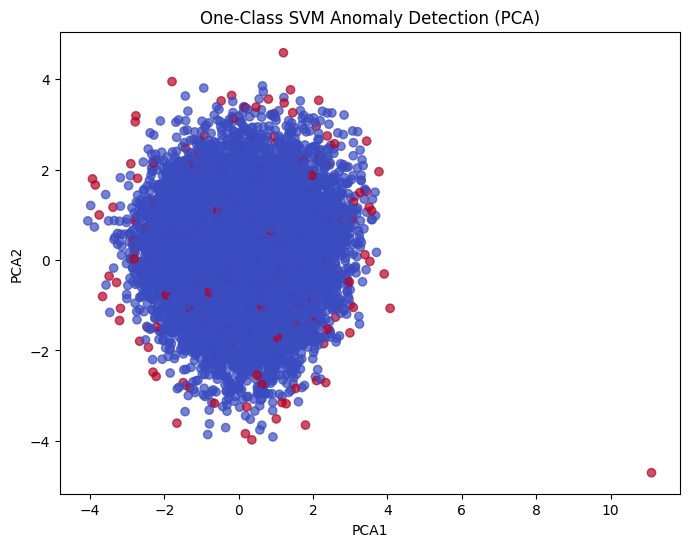

In [ ]:
plot_pca_anomalies(x_scaled,"anomaly_svm","One-Class SVM Anomaly Detection (PCA)")

The plot shows the PCA projection of the dataset with anomalies detected by a One-Class SVM. Most points (blue) are normal, while anomalies (red) appear on the edges or far from the dense cluster, indicating unusual or rare patterns in the data.

## ISO

In [ ]:
#Isolation Forest
cont_values = [0.01, 0.02, 0.03, 0.04, 0.05, 0.06]

In [ ]:
best_c, best_c_percent = find_best_param(model_type="iso",param_values=cont_values,x_data=raw_data)
print("best contamination:", best_c," percentage : ",best_c_percent)

0.01 1.0033273611466598
0.02 2.001535705144612
0.03 3.0048630662912723
0.04 4.003071410289224
0.05 5.001279754287177
0.06 6.004607115433837

Summary Table:
   Contamination  Outliers  Outlier %
0           0.01       196   1.003327
1           0.02       391   2.001536
2           0.03       587   3.004863
3           0.04       782   4.003071
4           0.05       977   5.001280
5           0.06      1173   6.004607
best contamination: 0.01  percentage :  1.0033273611466598


contamination = 0.01 was selected because it produced about 1.003% anomalies, which is within the required range(1-5%).

In [ ]:
#ISO
iso_forest = IsolationForest(n_estimators=100, contamination=best_c, random_state=42)
iso_forest.fit(x_scaled)
scores_pred = iso_forest.decision_function(x_scaled)
print(scores_pred)
iso_forest_pred = iso_forest.predict(x_scaled)
df["anomaly_iso"] = (iso_forest_pred == -1).astype(int)

[0.1678182  0.0115289  0.06297527 ... 0.09536339 0.16452075 0.17696115]


Isolation Forest scores each point for anomaly likelihood, and points with low scores are flagged as anomalies in the dataset

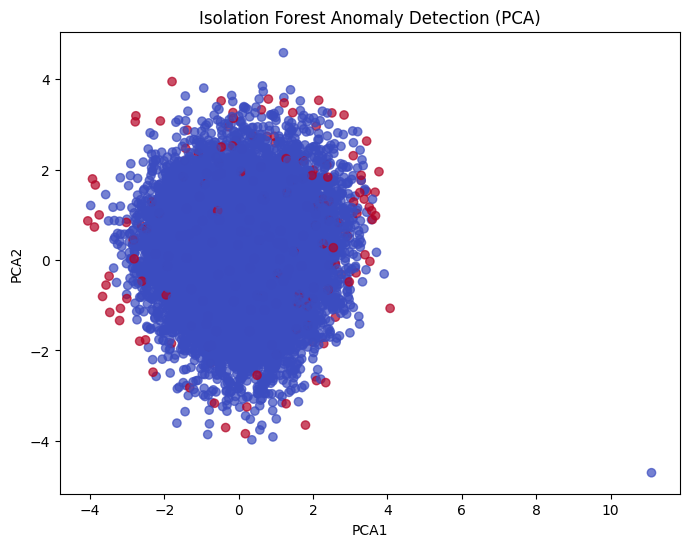

In [ ]:
#PCA + view plot
plot_pca_anomalies(x_scaled,"anomaly_iso","Isolation Forest Anomaly Detection (PCA)")

The PCA visualizations show no clear separation or clustering between normal and anomalous observations, indicating that anomalies are embedded within the same feature space as normal data rather than forming distinct groups.

# Data Analysis & Conclusion

The dataset was scaled and visualized using PCA on the same transformed features. The plot shows a dense central cluster with a few edge points, with no clear separation between normal and anomalous observations. This indicates that anomalies are embedded within the same feature space as normal data.

Both Isolation Forest (n_estimators = 100, contamination = 0.01) and One-Class SVM were evaluated using the same PCA projection. Isolation Forest performed best in identifying rare observations with unusual engine feature values.

# Recommendation

Flagged anomalies should be further investigated, as ships with extreme engine readings may require inspection or maintenance.

### Reference:
Devabrat, M., 2022. Predictive Maintenance on Ship's Main Engine using AI. Available at: https://dx.doi.org/10.21227/g3za-v415. [Accessed 5 March 2024]